In [2]:
source("~/bin/lit_utils.R")
lib_text()
lib_plot()
source("/rd1/user/lit/project/sORFs/sORFs.utils.R")

# msfragger和pfind的区别

In [2]:
msf <- read.csv("../results/msfragger_all.csv", stringsAsFactors = FALSE)
pfd <- read.csv("../results/pfind_all.csv", stringsAsFactors = FALSE)
all_db <- read.csv("../results/all_dbsearch.csv", stringsAsFactors = FALSE)

png 
  2

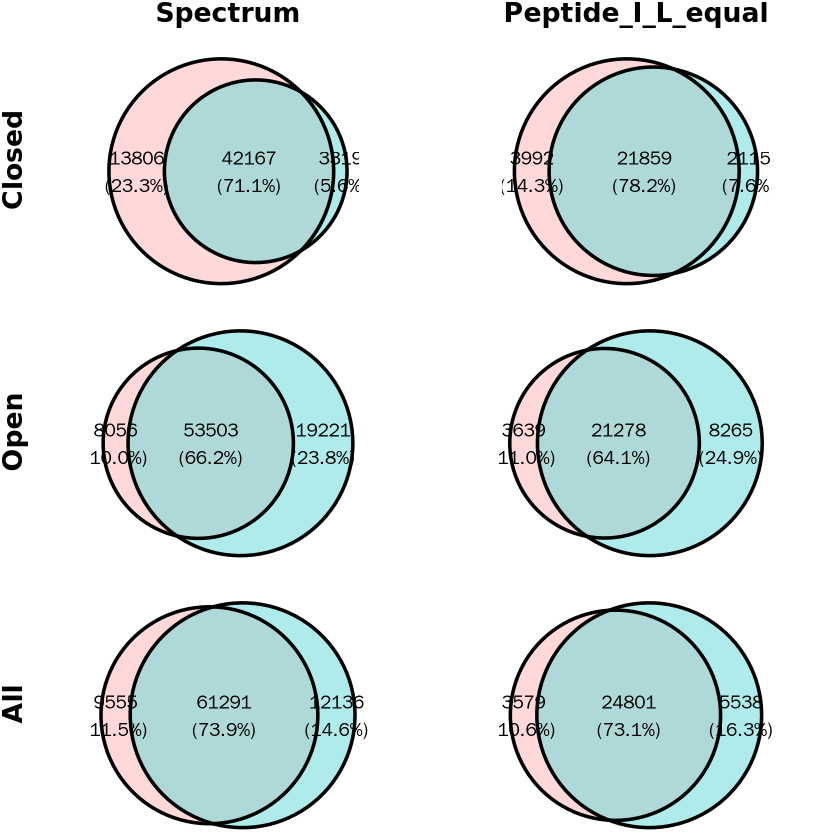

In [3]:
library(gridExtra)
library(grid)

# 1. closed
p1 <- venn_plot_n(list(
  msfragger_closed = all_db$Spectrum[all_db$Source == "msfragger_closed"],
  pfind_closed     = all_db$Spectrum[all_db$Source == "pfind_closed"]
))
p2 <- venn_plot_n(list(
  msfragger_closed = all_db$Peptide_I_L_equal[all_db$Source == "msfragger_closed"],
  pfind_closed     = all_db$Peptide_I_L_equal[all_db$Source == "pfind_closed"]
))

# 2. open
p3 <- venn_plot_n(list(
  msfragger_open = all_db$Spectrum[all_db$Source == "msfragger_open"],
  pfind_open     = all_db$Spectrum[all_db$Source == "pfind_open"]
))
p4 <- venn_plot_n(list(
  msfragger_open = all_db$Peptide_I_L_equal[all_db$Source == "msfragger_open"],
  pfind_open     = all_db$Peptide_I_L_equal[all_db$Source == "pfind_open"]
))

# 3. all
p5 <- venn_plot_n(list(
  msfragger = msf$Spectrum,
  pfind = pfd$Spectrum
))
p6 <- venn_plot_n(list(
  msfragger = msf$Peptide_I_L_equal,
  pfind = pfd$Peptide_I_L_equal
))

# 假设p1~p6已生成

# 列名
col1 <- textGrob("Spectrum", gp=gpar(fontsize=16, fontface="bold", fontfamily="ArialMT"))
col2 <- textGrob("Peptide_I_L_equal", gp=gpar(fontsize=16, fontface="bold", fontfamily="ArialMT"))

# 行名
row1 <- textGrob("Closed", rot=90, gp=gpar(fontsize=16, fontface="bold", fontfamily="ArialMT"))
row2 <- textGrob("Open", rot=90, gp=gpar(fontsize=16, fontface="bold", fontfamily="ArialMT"))
row3 <- textGrob("All", rot=90, gp=gpar(fontsize=16, fontface="bold", fontfamily="ArialMT"))

# 组合成大图
g <- arrangeGrob(
  # 第一行：空格+列名
  nullGrob(), col1, col2,
  # 第二行：行名+内容
  row1, p1, p2,
  row2, p3, p4,
  row3, p5, p6,
  ncol=3, nrow=4,
  heights = unit.c(unit(1, "lines"), unit(1, "null"), unit(1, "null"), unit(1, "null")),
  widths = unit.c(unit(1, "lines"), unit(1, "null"), unit(1, "null"))
)
grid.draw(g)
# 保存为pdf
pdf("../plot/msfragger_vs_pfind.pdf", width=6, height=9)
grid.draw(g)
dev.off()

In [48]:
table(all_db$Source)


msfragger_closed   msfragger_open     pfind_closed       pfind_open 
           55973            61559            45486            72724 

# msfragger和pfind的修饰类型

In [16]:
df1 <- read.table("../results/modi/pfind_non_standard_modi_row_stats.csv",sep = ',',header = T)
df2 <- read.table("../results/modi/msfragger_non_standard_modi_row_stats.csv",sep = ',',header = T)

In [17]:
head(df1)
head(df2)

,Modification,Count,Percentage
,<chr>,<int>,<dbl>
1,Carbamidomethyl[M],4903,25.66
2,Carbamidomethyl[AnyN-term],4850,25.39
3,Deamidated[N],4045,21.17
4,GG[C](Dicarbamidomethyl[C]),851,4.45
5,Carbamidomethyl[K](Gly[K]),607,3.18
6,Gln->pyro-Glu[AnyN-termQ],464,2.43


,Modification,Mass.Shift,Count,Percentage
,<chr>,<dbl>,<int>,<dbl>
1,Iodoacetamide derivative/Addition of Glycine/Addition of G,57.021464,3335,5.417
2,First isotopic peak,1.002350,1984,3.222
3,Deamidation,0.984016,1301,2.111
4,Isotopic peak error,-1.002350,711,1.155
5,Second isotopic peak,2.004700,711,1.154
6,amidination of lysines or N-terminal amines with methyl acetimidate,41.026549,568,0.923


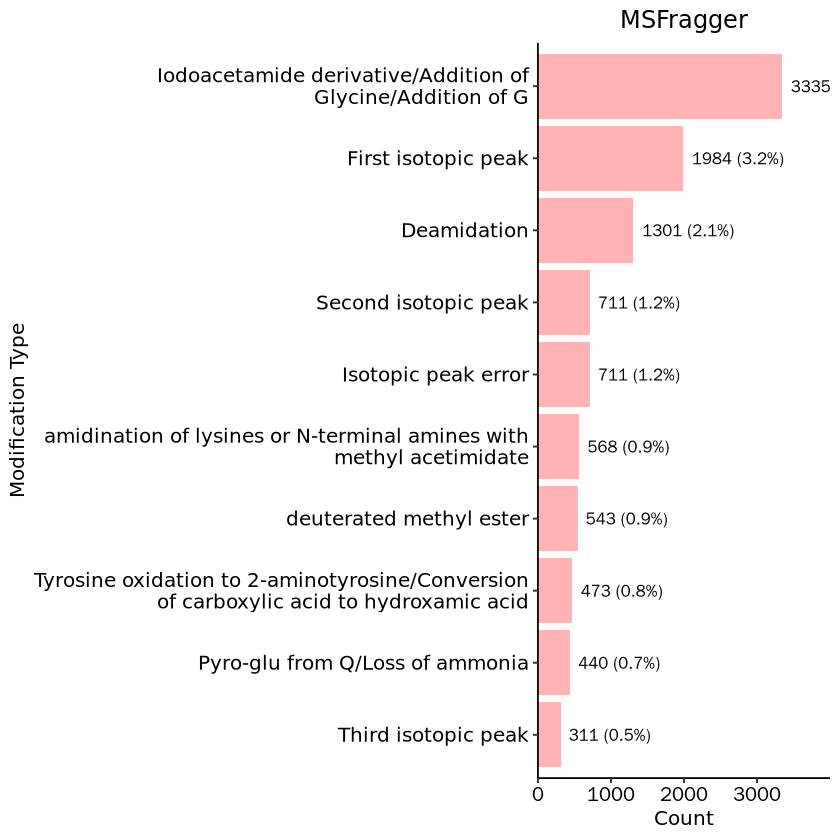

In [49]:
library(dplyr)
library(ggplot2)
library(forcats)
library(patchwork)  # 用于拼图

# 软件1处理
df1_top10 <- df1 %>%
  slice_max(order_by = Count, n = 10) %>%
  mutate(Modification = fct_reorder(str_wrap(Modification, width = 30), Count))  # ← 换行


p1 <- ggplot(df1_top10, aes(x = Modification, y = Count)) +
  geom_bar(stat = "identity", fill = hcl.colors(2, "Set3")[2]) +
  coord_flip() +
  labs(title = "pFind", x = "Modification Type", y = "Count") +
  theme_3()+
scale_y_continuous(expand = expansion(mult = c(0, 0.09)))+
  geom_text(aes(label = paste0(Count, " (", round(Percentage, 1), "%)")), 
            hjust = -0.1, size = 3.5)+
theme(plot.title = element_text(hjust = 0.5))+
  expand_limits(y = max(df1_top10$Count) * 1.1)

# 软件2处理
df2_top10 <- df2 %>%
  slice_max(order_by = Count, n = 10) %>%
  mutate(Modification = fct_reorder(str_wrap(Modification, width = 50), Count))  # ← 换行


p2 <- ggplot(df2_top10, aes(x = Modification, y = Count)) +
  geom_bar(stat = "identity", fill = hcl.colors(2, "Set3")[1]) +
  coord_flip() +
  labs(title = "MSFragger", x = "Modification Type", y = "Count") +
  theme_3()+
scale_y_continuous(expand = expansion(mult = c(0, 0.09)))+
  geom_text(aes(label = paste0(Count, " (", round(Percentage, 1), "%)")), 
            hjust = -0.1, size = 3.5)+
theme(plot.title = element_text(hjust = 0.5))+
  expand_limits(y = max(df2_top10$Count) * 1.1)


# 拼图展示
# p1 + p2
# p1

p2

In [50]:
ggsave(p1,filename = "../plot/pfind_modi_type.pdf",height = 5,width = 10)
ggsave(p2,filename = "../plot/msfragger_modi_type.pdf",height = 5,width = 10)

# denovo benchmark

## 比较casanovo, primenovo以及punifind

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


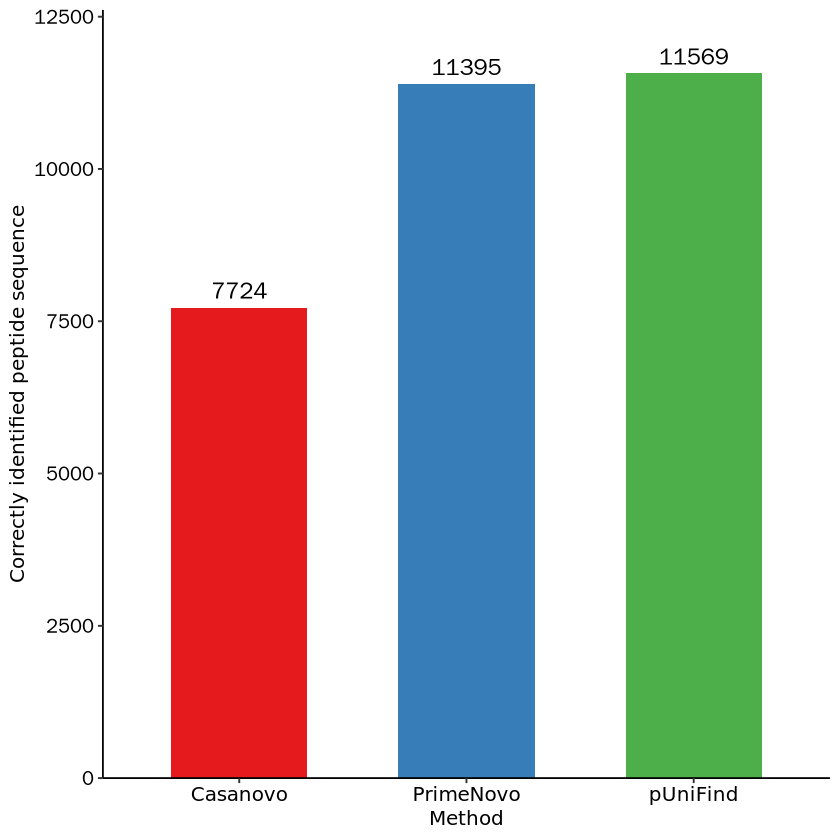

In [4]:
df <- read.table("../results/denovo_identified_peptide.txt",header = T)
df$Method <- c("Casanovo","PrimeNovo","pUniFind")
bar_plot_basic(df = df,x = "Method",y = "Identified_peptide_sequence",fil_col = "Method",label = T) +guides(fill="none")-> p
p+labs(y="Correctly identified peptide sequence") -> p
p
ggsave(p,filename = "../plot/identified_peptide_sequence.pdf",height = 5,width = 5)

## 比较primenovo以及punifind

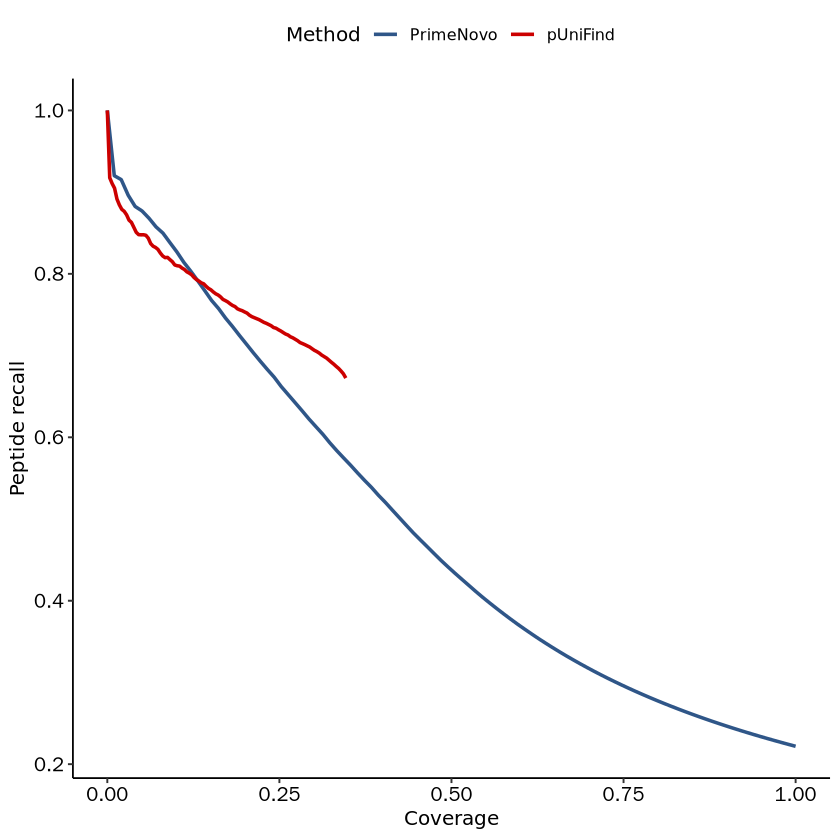

In [14]:
# 读取数据
primenovo_curve <- read.table("../results/primenovo_recall_coverage.tsv", header = TRUE, sep = "\t")
punifind_curve <- read.table("../results/punifind_recall_coverage.tsv", header = TRUE, sep = "\t")

# 合并
curve_df <- bind_rows(primenovo_curve, punifind_curve)

# 绘图
ggplot(curve_df, aes(x = coverage, y = recall, color = Method)) +
  geom_line(size = 1) +
  labs(x = "Coverage", y = "Peptide recall") +
  theme_3() +
#   scale_color_manual(values = c("#2f5688","#CC0000"))+
  scale_color_manual(
    values = c("primenovo" = "#2f5688", "punifind" = "#CC0000"),
    labels = c("primenovo" = "PrimeNovo", "punifind" = "pUniFind")
  ) ->p
p
ggsave(p,filename = "../plot/recall-coverage-plot.pdf",height = 5,width = 5)

# 谱图鉴定总来源

In [6]:
df <- read.table("../results/source_summary.tsv",header = T,sep='\t')
df

Source,Count
<chr>,<int>
MSFragger closed search,55973
MSFragger open search,14873
pFind open search,10146
pFind closed search,1990
PrimeNovo & pUniFind intersection,300
Unidentified (low quality spectra),32181


In [7]:
# 指定Source为有序因子，顺序为你想要的（从下到上）
df$Source <- factor(df$Source, levels = rev(c(
  "MSFragger closed search",
  "MSFragger open search",
  "pFind closed search",
  "pFind open search",
  "PrimeNovo & pUniFind intersection",
  "Unidentified (low quality spectra)"
)))

# 自定义颜色，最后一个为灰色
my_colors <- c(
  "MSFragger closed search" = "#4C72B0",
  "MSFragger open search" = "#55A868",
  "pFind closed search" = "#C44E52",
  "pFind open search" = "#8172B2",
  "PrimeNovo & pUniFind intersection" = "#FFA500",
  "Unidentified (low quality spectra)" = "grey60"
)

# 添加主分组变量（如Type），全部为"All"，用于堆叠
df$Type <- "All"

# 绘制堆叠柱状图
p <- ggplot(df, aes(x = Type, y = Count, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_manual(values = my_colors) +
  geom_text(aes(label = Count), 
            position = position_stack(vjust = 0.5), 
            color = "black", size = 5) +
  theme_3() +
  labs(x = NULL, y = "Count", fill = "Source") +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank())+
  scale_y_continuous(expand = expansion(mult = c(0, 0.09)))   # 只去掉底部空白
# print(p)
p+theme(legend.position = "right")->p
ggsave(p,filename = "../plot/identified_source.pdf",height = 5,width = 5)